# The Put-Write-Premium — a quantitative teardown 🔬
### CAPM alpha/beta on PUTW's real tape · a crash-conditional beta interaction · a block-bootstrapped Sharpe race · monthly capture and tail decomposition · a 20-seed synthetic null

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Truncated_beta%3F: Confirmed](https://img.shields.io/badge/Truncated_beta%3F-Confirmed-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). The claim — **systematic put-writing harvests the variance risk premium and beats buy-and-hold risk-adjusted** — has a genuine, well-documented mechanism (implied vol runs richer than realized vol on average) and a real academic anchor (the CBOE PUT index's long-run Sharpe advantage over 1986→2015). The job here is to test the *fund* that actually implements it, on its own live tape, and ask the only question that pays: is any of the outperformance beyond beta, and does it survive a crash?

> ⚠️ **Data note.** PUTW / SPY / BIL daily auto-adjusted closes, 2016-02-24 → 2026-06-30 (2,600 daily returns), yfinance, cached. Window is bound by PUTW's own inception — not the longer, untradeable CBOE PUT index. No survivorship (both funds are live, currently-listed, measured over their full window). Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md) (fingerprint `3a3191a10828`).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from put_write_premium import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    PX = data.load_real()
    RET = st.daily_returns(PX)
    EX = st.excess(RET, cash_col=data.CASH)
else:
    PX = RET = EX = None
print("real cache present:", HAVE_REAL, "| joint trading days:", (0 if PX is None else len(PX)))

# frozen headline numbers (mirror of docs/results.md)
R = {'start': '2016-02-24', 'end': '2026-06-30', 'n': 2600, 'n_rows': 2601, 'putw_excess_ann': 6.78, 'putw_excess_t': 2.0, 'spy_excess_ann': 14.26, 'spy_excess_t': 2.9, 'gap_ann': -7.48, 'gap_t': -3.21, 'sharpe_putw': 0.53, 'sharpe_spy': 0.8, 'sharpe_gap': -0.27, 'boot_lo': -0.48, 'boot_hi': -0.0, 'boot_win_pct': 2.4, 'alpha_ann': -1.78, 'alpha_t': -0.95, 'beta': 0.6, 'beta_t': 10.26, 'cb_normal': 0.551, 'cb_normal_t': 14.05, 'cb_extra': 0.382, 'cb_extra_t': 2.34, 'cb_total': 0.932, 'n_crash_days': 33, 'volm_putw': -8.2, 'volm_spy': -10.1, 'covid_putw': -28.4, 'covid_spy': -33.7, 'mdd_putw': -28.4, 'mdd_spy': -33.7, 'n_months': 124, 'n_up': 89, 'n_dn': 35, 'cap_up': 59.3, 'cap_dn': 65.8, 'worst_m_putw': -13.1, 'worst_m_spy': -12.5, 'worst_m_date': '2020-03', 'vol_putw': 12.7, 'vol_spy': 17.8, 'skew_putw': -1.8, 'skew_spy': -0.32, 'worst_d_putw': -10.51, 'worst_d_spy': -10.94, 'syn_null_t_mean': -0.53, 'syn_null_t_sd': 0.98, 'syn_null_fire': 1, 'syn_planted_alpha': 4.69, 'syn_planted_t': 4.25, 'fp': '3a3191a10828'}


real cache present: True | joint trading days: 2601


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | excess gap vs SPY **-7.48%/yr** (HAC *t* = -3.21); Sharpe **0.53 vs 0.80**, bootstrap 95% CI **[-0.48, -0.00]**; CAPM alpha **-1.78%/yr at *t* = -0.95** |
| **Tradability** | `MIRAGE` | beta widens from **0.55** (normal) to **0.93** (crash days, *t* = +2.34); worst month **-13.1%** beats SPY's own worst month (-12.5%) |
| **Truncated beta?** | `CONFIRMED` | beta **0.600** (*t* = +10.26) explains the average day; alpha statistically zero |

> 💡 In plain words: the fund is a smaller, less stable slice of SPY's own market risk — not a distinct risk-adjusted edge.

## 1 · The claim, steelmanned

Let $r^{ex}_{putw,t} = r_{putw,t} - r_{bil,t}$ and $r^{ex}_{spy,t} = r_{spy,t} - r_{bil,t}$ be daily excess-of-cash returns. The claims:

- **H₁ (premium exists).** $E[r^{ex}_{putw,t}] > 0$ — PUTW earns something over cash.
- **H₂ (beats buy-and-hold, risk-adjusted).** $\text{Sharpe}(r^{ex}_{putw}) \ge \text{Sharpe}(r^{ex}_{spy})$.
- **H₃ (genuine alpha, not just beta).** In $r^{ex}_{putw,t} = \alpha + \beta \, r^{ex}_{spy,t} + \epsilon_t$, $\alpha$ is significantly positive.
- **H₄ (stable protection).** $\beta$ does not widen materially on the market's worst days.

We find **H₁ marginal** (excess return +6.78%/yr, HAC *t* = +2.00 — right at the desk's own bar, not comfortably above it), **H₂ rejected** (Sharpe 0.53 < 0.80, bootstrap CI excludes zero on the losing side), **H₃ rejected** (alpha *t* = -0.95), **H₄ rejected** (crash-beta interaction *t* = +2.34).

## 2 · So what? — inference design

Every excess-of-cash number here is measured against **BIL** (the T-bill ETF), the same convention as sibling study 655-ivy-portfolio, so no Sharpe race compares a raw return to an excess return. The CAPM regression is the honest version of "is the premium real" — a **Newey-West (HAC, 10 daily lags)** *t* on both the intercept (alpha) and the slope (beta); the crash-conditional beta adds an **interaction term** on an *ex-ante*, non-snooped threshold (SPY daily return ≤ −3%) rather than a full-sample quantile that would risk fitting the tail it's meant to test. The Sharpe race between PUTW and SPY runs a **circular block bootstrap** (block = 21 trading days ≈ one option roll) on the *difference*, not a single point estimate.

## 3 · How we'd know — the protocol

- **Tape.** PUTW / SPY / BIL daily auto-adjusted closes, 2016-02-24 → 2026-06-30 (2,600 returns) — PUTW's own inception is the binding constraint, not the longer CBOE PUT index. As-of 2026-06-30 (last complete month).
- **Headline.** Excess-of-cash HAC *t* for each leg + the paired excess-return gap + Sharpe with a bootstrap CI on the difference.
- **Alpha vs beta.** CAPM regression, HAC-robust, both coefficients.
- **Crash conditioning.** An interaction regression: normal-day beta vs an extra crash-day slope on an ex-ante threshold.
- **Cross-checks.** Named crash-window drawdowns, monthly up/down capture, daily skew and worst-day/worst-month comparisons.
- **Execution.** Zero look-ahead by construction — realized returns of an already-listed fund, nothing timed.
- **Control.** A synthetic Black-Scholes cash-secured-put engine with a tunable VRP knob; the alpha detector must not fire on a fairly-priced null across 20 seeds.

## 4 · The teardown

### 4a · The headline split — excess-of-cash return and the Sharpe race

Both legs' excess-of-cash return (HAC *t*), the paired gap, and a circular block bootstrap on the Sharpe difference.

PUTW-BIL +6.78%/yr (t=+2.00)   SPY-BIL +14.26%/yr (t=+2.90)
gap -7.48%/yr  t=-3.21
Sharpe 0.53 vs 0.80   bootstrap CI [-0.48, -0.00]


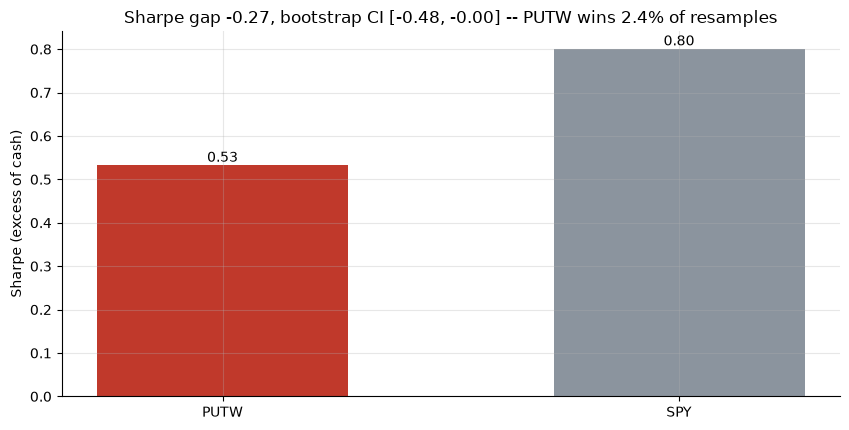

In [2]:
if HAVE_REAL:
    ex_p, ex_s = EX['PUTW'].to_numpy(), EX['SPY'].to_numpy()
    rp = st.excess_return_stats(ex_p); rs = st.excess_return_stats(ex_s)
    diff = st.hac_mean_t(ex_p - ex_s, lags=10)
    sh_p, sh_s = st.sharpe_ann(ex_p), st.sharpe_ann(ex_s)
    bs = st.bootstrap_sharpe_diff(ex_p, ex_s)
    print(f"PUTW-BIL {rp['ann_pct']:+.2f}%/yr (t={rp['t']:+.2f})   "
          f"SPY-BIL {rs['ann_pct']:+.2f}%/yr (t={rs['t']:+.2f})")
    print(f"gap {diff['mean']*252*100:+.2f}%/yr  t={diff['t']:+.2f}")
    print(f"Sharpe {sh_p:.2f} vs {sh_s:.2f}   bootstrap CI [{bs['ci_lo']:+.2f}, {bs['ci_hi']:+.2f}]")
    lo, hi, win = bs['ci_lo'], bs['ci_hi'], bs['frac_putw_wins']*100
else:
    sh_p, sh_s, lo, hi, win = R['sharpe_putw'], R['sharpe_spy'], R['boot_lo'], R['boot_hi'], R['boot_win_pct']
fig, ax = plt.subplots(figsize=(8.6, 4.4))
ax.bar(['PUTW', 'SPY'], [sh_p, sh_s], color=[RED, GREY], width=.55)
for i, v in enumerate([sh_p, sh_s]): ax.annotate(f'{v:.2f}', (i, v), ha='center', va='bottom')
ax.set_ylabel('Sharpe (excess of cash)')
ax.set_title(f'Sharpe gap {sh_p-sh_s:+.2f}, bootstrap CI [{lo:+.2f}, {hi:+.2f}] '
             f'-- PUTW wins {win:.1f}% of resamples')
plt.tight_layout(); plt.show()

> 💡 In plain words: PUTW earns +6.78%/yr over cash (HAC *t* = +2.00 — right at, not above, the desk's *t* ≥ 2 bar), SPY earns +14.26%/yr (*t* = +2.90). The gap (-7.48%/yr, *t* = -3.21) and the Sharpe bootstrap (CI [-0.48, -0.00], PUTW wins only 2.4% of draws) both point the same way: on this fund's entire live tape, H₂ is rejected.

### 4b · Alpha vs beta — the CAPM split

$r^{ex}_{putw,t} = \alpha + \beta \, r^{ex}_{spy,t} + \epsilon_t$, HAC (10 lags).

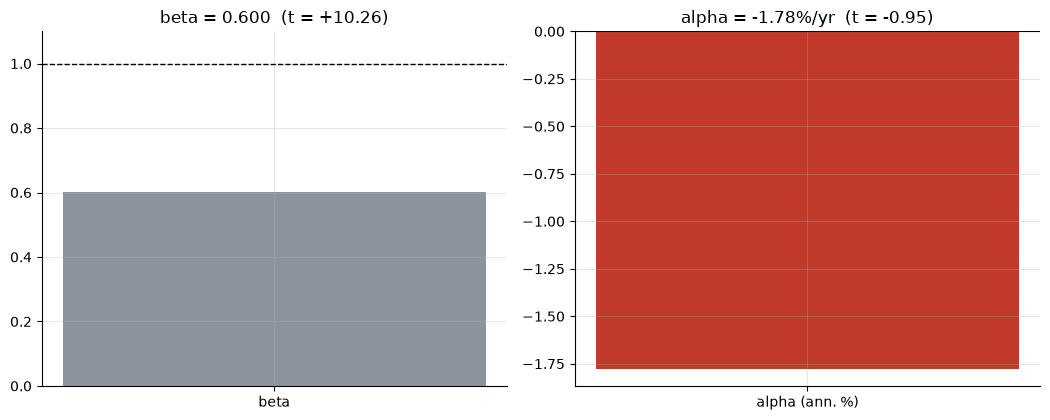

alpha -1.78%/yr (t=-0.95)   beta 0.600 (t=+10.26)


In [3]:
if HAVE_REAL:
    cb = st.capm_alpha_beta(EX['PUTW'].to_numpy(), EX['SPY'].to_numpy())
    alpha, beta, ta, tb = cb['alpha_ann_pct'], cb['beta'], cb['t_alpha'], cb['t_beta']
else:
    alpha, beta, ta, tb = R['alpha_ann'], R['beta'], R['alpha_t'], R['beta_t']
fig, (a1, a2) = plt.subplots(1, 2, figsize=(10.6, 4.3))
a1.bar(['beta'], [beta], color=GREY, width=.5)
a1.axhline(1.0, ls='--', c='k', lw=1)
a1.set_title(f'beta = {beta:.3f}  (t = {tb:+.2f})'); a1.set_ylim(0, 1.1)
a2.bar(['alpha (ann. %)'], [alpha], color=[RED if abs(ta) < 2 else GREEN], width=.5)
a2.axhline(0, c='k', lw=.8)
a2.set_title(f'alpha = {alpha:+.2f}%/yr  (t = {ta:+.2f})')
plt.tight_layout(); plt.show()
print(f'alpha {alpha:+.2f}%/yr (t={ta:+.2f})   beta {beta:.3f} (t={tb:+.2f})')

> 💡 In plain words: beta = **0.600** at *t* = +10.26 — PUTW's average-day behavior is almost entirely explained by holding about 60% of SPY's market exposure. Alpha = **-1.78%/yr** at *t* = -0.95 — statistically zero, point estimate even negative. H₃ is rejected: there is no measurable premium beyond beta on this tape.

### 4c · Does the lower beta survive a crash?

$r^{ex}_{putw,t} = \alpha + \beta_0 r^{ex}_{spy,t} + \gamma D_t + \delta (D_t \cdot r^{ex}_{spy,t}) + \epsilon_t$, $D_t = \mathbf{1}\{r_{spy,t} \le -3\%\}$ — an ex-ante threshold, not a full-sample quantile.

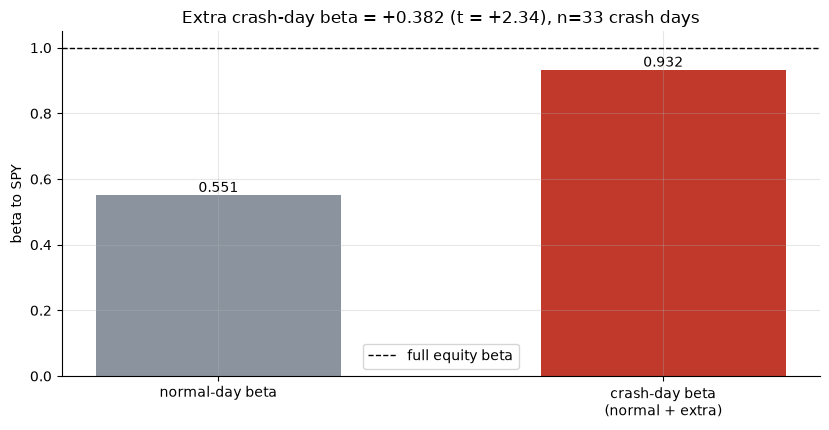

In [4]:
if HAVE_REAL:
    cx = st.crash_beta_interaction(EX['PUTW'].to_numpy(), EX['SPY'].to_numpy(),
                                    RET['SPY'].to_numpy(), threshold=data.CRASH_DAY_THRESHOLD)
    bn, be, bt, ncrash = cx['beta_normal'], cx['crash_beta_extra'], cx['t_crash_beta_extra'], cx['n_crash_days']
else:
    bn, be, bt, ncrash = R['cb_normal'], R['cb_extra'], R['cb_extra_t'], R['n_crash_days']
fig, ax = plt.subplots(figsize=(8.4, 4.4))
ax.bar(['normal-day beta', 'crash-day beta\n(normal + extra)'], [bn, bn + be],
       color=[GREY, RED], width=.55)
for i, v in enumerate([bn, bn + be]): ax.annotate(f'{v:.3f}', (i, v), ha='center', va='bottom')
ax.axhline(1.0, ls='--', c='k', lw=1, label='full equity beta')
ax.set_ylabel('beta to SPY'); ax.legend()
ax.set_title(f'Extra crash-day beta = {be:+.3f} (t = {bt:+.2f}), n={ncrash} crash days')
plt.tight_layout(); plt.show()

> 💡 In plain words: normal-day beta = **0.551** (*t* = +14.05); on the **33** days SPY fell 3%+, beta gains an extra **+0.382** (*t* = +2.34, significant), pushing the crash-day beta to **≈0.932** — essentially full equity exposure. H₄ is rejected: the 'lower risk' is not a stable property, it is a normal-times property that fades exactly when a diversifier is supposed to earn its keep.

### 4d · Named crash windows, monthly capture, and the tail signature

Cross-checks: drawdowns in the two named vol shocks, monthly up/down capture (Morningstar-style mean-return ratio), and the worst single day/month each way.

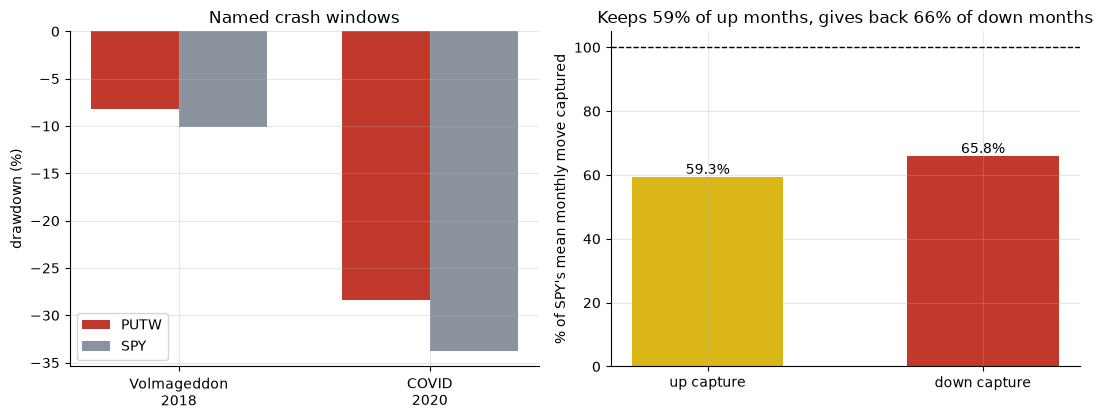

worst month: PUTW -13.1%  vs SPY -12.5%


In [5]:
if HAVE_REAL:
    dd = {name: (st.window_drawdown(RET['PUTW'], s, e)*100, st.window_drawdown(RET['SPY'], s, e)*100)
          for name, (s, e) in data.CRASH_WINDOWS.items()}
    cap = st.monthly_capture(PX)
    up_c, dn_c = cap['up_capture']*100, cap['dn_capture']*100
    wm_p, wm_s = cap['worst_month_putw']*100, cap['worst_month_spy']*100
else:
    dd = {'volmageddon_2018': (R['volm_putw'], R['volm_spy']),
          'covid_2020': (R['covid_putw'], R['covid_spy'])}
    up_c, dn_c = R['cap_up'], R['cap_dn']
    wm_p, wm_s = R['worst_m_putw'], R['worst_m_spy']
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11.0, 4.3))
names = list(dd.keys())
p_vals = [dd[n][0] for n in names]; s_vals = [dd[n][1] for n in names]
x = np.arange(len(names)); w = 0.35
a1.bar(x - w/2, p_vals, w, color=RED, label='PUTW')
a1.bar(x + w/2, s_vals, w, color=GREY, label='SPY')
a1.set_xticks(x); a1.set_xticklabels(['Volmageddon\n2018', 'COVID\n2020'])
a1.set_ylabel('drawdown (%)'); a1.legend(); a1.set_title('Named crash windows')
a2.bar(['up capture', 'down capture'], [up_c, dn_c], color=[AMBER, RED], width=.55)
a2.axhline(100, ls='--', c='k', lw=1)
for i, v in enumerate([up_c, dn_c]): a2.annotate(f'{v:.1f}%', (i, v), ha='center', va='bottom')
a2.set_ylabel('% of SPY\'s mean monthly move captured')
a2.set_title('Keeps 59% of up months, gives back 66% of down months')
plt.tight_layout(); plt.show()
print(f'worst month: PUTW {wm_p:+.1f}%  vs SPY {wm_s:+.1f}%')

> 💡 In plain words: PUTW looks protective in both named windows (**-8.2%** vs SPY -10.1% in 2018; **-28.4%** vs -33.7% in 2020) — but that is exactly what a beta-0.6 asset does in any broad drawdown, and does not contradict 4c. The capture asymmetry (59.3% up / 65.8% down) is the textbook short-vol shape, and the sharpest single number: despite 29% less annualized volatility than SPY, PUTW's single worst month (**-13.1%**, 2020-03) was *worse* than SPY's own worst month (**-12.5%**). A lower-vol asset with a fatter left tail than its own benchmark is the fingerprint of a truncated-upside payoff, not a genuine risk reducer.

### 4e · Faithful-engine & power control — we know the truth here

Deterministic monthly cash-secured-ATM-put engine (Black-Scholes premium, `data.bs_atm_put`), options priced at `realized_vol × (1 + harvest)`. `harvest = 0` embeds **no** volatility risk premium; the CAPM-alpha detector must not manufacture significance there. Null checked over **20 seeds**.

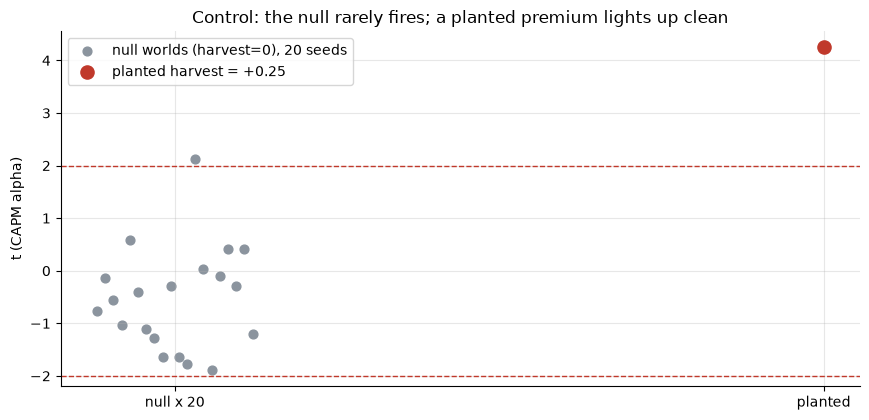

null: mean t = -0.53 (sd 0.98), |t|>=2 in 1/20 seeds  |  planted t = +4.25


In [6]:
null_ts = []
for s_ in range(20):
    w = data.synthetic_world(harvest=0.0, seed=658 + s_)
    null_ts.append(st.synthetic_detect(w)['t_alpha'])
null_ts = np.asarray(null_ts)
w = data.synthetic_world(harvest=0.25, seed=658)
sy = st.synthetic_detect(w)
fig, ax = plt.subplots(figsize=(8.8, 4.3))
ax.scatter(np.zeros(20) + np.linspace(-.12, .12, 20), null_ts, color=GREY, s=40,
           label='null worlds (harvest=0), 20 seeds')
ax.scatter([1], [sy['t_alpha']], color=RED, s=90, zorder=5,
           label='planted harvest = +0.25')
ax.axhline(-2, ls='--', c=RED, lw=1); ax.axhline(2, ls='--', c=RED, lw=1)
ax.set_xticks([0, 1]); ax.set_xticklabels(['null x 20', 'planted'])
ax.set_ylabel('t (CAPM alpha)')
ax.set_title('Control: the null rarely fires; a planted premium lights up clean')
ax.legend(); plt.tight_layout(); plt.show()
print(f'null: mean t = {null_ts.mean():+.2f} (sd {null_ts.std(ddof=1):.2f}), '
      f'|t|>=2 in {(abs(null_ts)>=2).sum()}/20 seeds  |  planted t = {sy["t_alpha"]:+.2f}')

> 💡 In plain words: across 20 null worlds the detector averages *t* = -0.53 (sd 0.98) and fires in only **1/20** seeds — about the nominal 5% false-positive rate, correctly calibrated, not over- or under-powered. A planted premium (alpha +4.69%/yr) reads *t* = +4.25 — clean detection. The machinery is unbiased; the real tape's insignificant alpha (*t* = −0.95) is the genuine article, not a blind spot in the test. *(A faithful-engine / power check only — never cited in support of the real-tape stamp.)*

## 5 · The verdict

- **Signal `NONE`** — excess-of-cash return is marginal at best (+6.78%/yr, *t* = +2.00); the actual claim (beats buy-and-hold risk-adjusted) is rejected decisively: gap vs SPY **-7.48%/yr** at *t* = **-3.21**, Sharpe **0.53 vs 0.80** with a bootstrap CI [-0.48, -0.00], CAPM alpha statistically zero (*t* = -0.95).
- **Tradability `MIRAGE`** — beta widens from **0.55** to **0.93** (*t* = +2.34) on the worst days, and the worst single month (**-13.1%**) beat SPY's own worst month (**-12.5%**) despite 12.7% vs 17.8% annualized vol; no residual edge survives the fund's own cost structure because there was never one to begin with.
- **Truncated beta? `CONFIRMED`** — beta 0.600 (*t* = +10.26) explains the average day, alpha is statistically zero, and the beta itself is unstable — converging toward full equity exposure precisely on the days a diversifier is supposed to prove its worth.

## 6 · Going further

- **The premium is real; the packaging is the problem.** [130-vol-risk-premium](../../130-vol-risk-premium/) shows implied vol systematically exceeds realized vol (HAC *t* = +22.9) — this study shows a real monthly-roll ETF did not translate that into alpha beyond beta over its own decade. The gap between "the premium exists" and "a fund banks it net of beta and costs" is the whole story.
- **The crash-conditional-beta test is the general lesson.** Any short-vol wrapper — covered calls, the Wheel, tail-hedge sellers — should be tested for whether its 'lower risk' is stable or regime-dependent; a single full-sample beta hides exactly the failure mode that matters.
- **Dedup map:** [62-premium-seller](../../62-premium-seller/) and [337-covered-call-etf](../../337-covered-call-etf/) (the call side), [354-the-wheel](../../354-the-wheel/) (both legs, model-priced), [130-vol-risk-premium](../../130-vol-risk-premium/) (the raw premium, no fund), [617-crash-insurance-cost](../../617-crash-insurance-cost/) (the buyer's mirror image) — none of them run the CAPM-alpha-vs-beta and crash-interaction test this study runs on PUTW's own live tape.

*The reproducible core is offline and deterministic; frozen numbers live in [`docs/results.md`](../docs/results.md), sources in [`docs/references.md`](../docs/references.md).*